In [13]:


from pathlib import Path
import pydicom

# Point this to your .IMA path
file_path = Path("../Data/Organized_DICOM_4DFlow/Anonymous/Unknown/001_20240313_3T_1.MR.0017.0001.2024.03.26.12.11.25.918220.61293773.IMA")

# stop_before_pixels=True skips pixel data for speed; set to False if you also want pixel-related tags
ds = pydicom.dcmread(file_path, stop_before_pixels=True)

for elem in ds.iterall():  # iterall walks the full dataset, including sequences
    # elem.tag is a pydicom Tag; elem.name is the keyword/name; elem.value is the stored value
    print(f"{elem.tag} | {elem.name} | {elem.value}")

(0008, 0005) | Specific Character Set | ISO_IR 100
(0008, 0008) | Image Type | ['DERIVED', 'PRIMARY', 'MSUM', 'RETRO', 'NORM', 'DIS2D']
(0008, 0012) | Instance Creation Date | 20240313
(0008, 0013) | Instance Creation Time | 115538.423000
(0008, 0016) | SOP Class UID | 1.2.840.10008.5.1.4.1.1.4
(0008, 0018) | SOP Instance UID | 1.3.12.2.1107.5.2.43.166117.30000024032611113273900004003
(0008, 0020) | Study Date | 20240313
(0008, 0021) | Series Date | 20240313
(0008, 0022) | Acquisition Date | 20240313
(0008, 0023) | Content Date | 20240313
(0008, 0030) | Study Time | 111005.778000
(0008, 0031) | Series Time | 115538.422000
(0008, 0032) | Acquisition Time | 112528.565000
(0008, 0033) | Content Time | 115538.423000
(0008, 0050) | Accession Number | 
(0008, 0060) | Modality | MR
(0008, 0070) | Manufacturer | SIEMENS
(0008, 0090) | Referring Physician's Name | 
(0008, 1090) | Manufacturer's Model Name | Prisma
(0008, 1140) | Referenced Image Sequence | [(0008, 1150) Referenced SOP Class UID

In [4]:
import os
import shutil
import pydicom
import re

def limpiar_nombre(texto):
    """Elimina caracteres extraños para usar como nombre de carpeta"""
    return re.sub(r'[^a-zA-Z0-9_-]', '_', str(texto))

def clasificar_archivo_v4(file_path):
    """
    Retorna una tupla (Categoria_Principal, Nombre_Especifico_Serie)
    """
    try:
        ds = pydicom.dcmread(file_path, stop_before_pixels=True)
        
        # 1. Obtener datos descriptivos
        p_name = str(ds.get("ProtocolName", "NoProto")).strip()
        s_desc = str(ds.get("SeriesDescription", "NoSeries")).strip()
        seq_name = str(ds.get("SequenceName", "")).strip()
        
        # Usar ProtocolName preferiblemente, o SeriesDescription si falla
        # Si el nombre es muy genérico, agregamos SequenceName para diferenciar
        nombre_serie = p_name if len(p_name) > 3 else s_desc
        if seq_name:
            nombre_serie += f"_{seq_name}"
            
        nombre_serie = limpiar_nombre(nombre_serie)
        
        # Combinar texto para detección de dirección
        full_header_info = f"{p_name} {s_desc} {seq_name}".lower()
        
        # 2. Clasificación Tipo
        image_type = ds.get("ImageType", [])
        image_type_str = [x.upper() for x in image_type]

        categoria = "Unknown"

        # Detección
        if 'MSUM' in image_type_str:
            categoria = "Magnitude_MSUM"
        elif any(x in image_type_str for x in ['M', 'MAGNITUDE']):
            categoria = "Magnitude"
        elif any(x in image_type_str for x in ['P', 'PHASE', 'V', 'VELOCITY']):
            if any(x in full_header_info for x in ['rl', 'right', 'flow_x', 'in_plane']):
                categoria = "Phase_Vx"
            elif any(x in full_header_info for x in ['ap', 'anterior', 'flow_y']):
                categoria = "Phase_Vy"
            elif any(x in full_header_info for x in ['in', 'fh', 'foot', 'head', 'flow_z']):
                categoria = "Phase_Vz"
            else:
                categoria = "Phase_Other"
        else:
            # Fallback para casos raros (ej. derivadas sin tag P/M claro)
            if "pc3d" in full_header_info or "flow" in full_header_info:
                if "rl" in full_header_info: categoria = "Phase_Vx"
                elif "ap" in full_header_info: categoria = "Phase_Vy"
                elif "in" in full_header_info: categoria = "Phase_Vz"
                else: categoria = "Magnitude"
        
        return categoria, nombre_serie

    except Exception:
        return None, None

def procesar_pacientes_final(root_input_dir, root_output_dir):
    print(f"--- Iniciando Organización Detallada ---")
    print(f"Origen: {root_input_dir}")
    print(f"Destino: {root_output_dir}\n")

    pacientes = [d for d in os.listdir(root_input_dir) 
                 if os.path.isdir(os.path.join(root_input_dir, d)) 
                 and d != os.path.basename(root_output_dir)]
    
    for i, paciente in enumerate(pacientes):
        path_paciente = os.path.join(root_input_dir, paciente)
        print(f"[{i+1}/{len(pacientes)}] Paciente: {paciente}")
        
        conteo_carpetas = {}

        for root, dirs, files in os.walk(path_paciente):
            for filename in files:
                if filename.upper().endswith((".IMA", ".DCM")):
                    file_path = os.path.join(root, filename)
                    
                    categoria, nombre_serie = clasificar_archivo_v4(file_path)
                    
                    if categoria:
                        # NOMBRE DE CARPETA FINAL: Categoria + NombreSerie
                        # Ej: Magnitude_fl3d1r_t70
                        folder_name = f"{categoria}_{nombre_serie}"
                        
                        dest_path = os.path.join(root_output_dir, paciente, folder_name)
                        if not os.path.exists(dest_path):
                            os.makedirs(dest_path)
                        
                        shutil.copy2(file_path, os.path.join(dest_path, filename))
                        
                        # Contar para el reporte
                        conteo_carpetas[folder_name] = conteo_carpetas.get(folder_name, 0) + 1

        # Imprimir resumen de qué carpetas se crearon para este paciente
        for carpeta, count in conteo_carpetas.items():
            print(f"   -> {carpeta}: {count} imgs")
        print("")

# --- CONFIGURACIÓN ---
ruta_origen = r"../Data/Disease Patients"
ruta_destino = r"../Data/Disease Patients/sorted_patients"

if __name__ == "__main__":
    procesar_pacientes_final(ruta_origen, ruta_destino)

--- Iniciando Organización Detallada ---
Origen: ../Data/Disease Patients
Destino: ../Data/Disease Patients/sorted_patients

[1/15] Paciente: 005_20241211_3T
   -> Magnitude_NoProto_WIP_pc3d1r3: 624 imgs
   -> Phase_Vy_NoProto_WIP_p_v090ap: 624 imgs
   -> Phase_Vx_NoProto_WIP_p_v090rl: 624 imgs
   -> Phase_Vz_NoProto_WIP_p_v090in: 624 imgs
   -> Magnitude_NoProto__fl3d1r_t70: 136 imgs

[2/15] Paciente: 002_20240326_7T
   -> Magnitude_NoProto_WIP_fl3d1r3: 480 imgs
   -> Phase_Vy_NoProto_WIP_f_v090ap: 480 imgs
   -> Phase_Vx_NoProto_WIP_f_v090rl: 480 imgs
   -> Magnitude_NoProto__fl3d1_ns: 128 imgs
   -> Phase_Vz_NoProto_WIP_f_v090in: 480 imgs
   -> Unknown_NoProto__fl3d1_ns: 11 imgs
   -> Magnitude_NoProto__fl3d1r_t70: 116 imgs

[3/15] Paciente: 001_20240313_3T
   -> Magnitude_NoProto_WIP_pc3d1r3: 432 imgs
   -> Magnitude_MSUM_NoProto_WIP_pc3d1r3: 432 imgs
   -> Phase_Vy_NoProto_WIP_p_v090ap: 432 imgs
   -> Phase_Vz_NoProto_WIP_p_v090in: 432 imgs
   -> Magnitude_NoProto__fl3d1r_t70: 136

# Check Orientation

Current orientation (data): ('R', 'A', 'S')
Original shape: (448, 448, 48, 9)
Showing t = 4


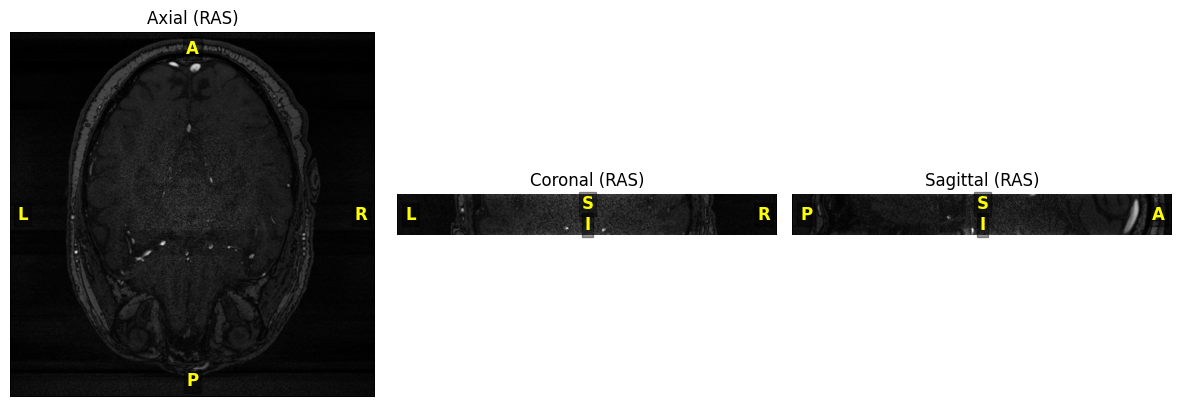

In [9]:
# Visualize NIfTI orientation (3D/4D) with direction labels
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nibabel.orientations import aff2axcodes, io_orientation
from nibabel.orientations import apply_orientation

# Path to the NIfTI file (adjust to your case)
nifti_path = "../data/nifti_patients/001_20240313_3T/Magnitude_NoProto_WIP_pc3d1r3.nii.gz"

img = nib.load(nifti_path)
data = img.get_fdata()
affine = img.affine

# Axis codes (L/R, A/P, S/I) in data order
axcodes = aff2axcodes(affine)
print("Current orientation (data):", axcodes)
print("Original shape:", data.shape)

# Reorient to RAS (Right-Anterior-Superior) for consistent viewing
# This does not change the file on disk; it only creates a reoriented view
ornt = io_orientation(affine)
ras_ornt = nib.orientations.axcodes2ornt(("R", "A", "S"))
transform = nib.orientations.ornt_transform(ornt, ras_ornt)
data_ras = apply_orientation(data, transform)

# If 4D, select a timepoint (or average) for visualization
if data_ras.ndim == 4:
    t = data_ras.shape[3] // 2  # middle timepoint
    vol = data_ras[:, :, :, t]
    print("Showing t =", t)
else:
    vol = data_ras

def add_labels(ax, left, right, top, bottom):
    ax.text(0.02, 0.5, left, transform=ax.transAxes, va="center", ha="left",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.text(0.98, 0.5, right, transform=ax.transAxes, va="center", ha="right",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.text(0.5, 0.98, top, transform=ax.transAxes, va="top", ha="center",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.text(0.5, 0.02, bottom, transform=ax.transAxes, va="bottom", ha="center",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))

# Central slices for each plane
z = vol.shape[2] // 2
y = vol.shape[1] // 2
x = vol.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Axial: R/L (left-right), A/P (top-bottom) in RAS
axial = vol[:, :, z].T
axes[0].imshow(axial, cmap="gray", origin="lower")
axes[0].set_title("Axial (RAS)")
axes[0].axis("off")
add_labels(axes[0], left="L", right="R", top="A", bottom="P")

# Coronal: R/L (left-right), S/I (top-bottom) in RAS
coronal = vol[:, y, :].T
axes[1].imshow(coronal, cmap="gray", origin="lower")
axes[1].set_title("Coronal (RAS)")
axes[1].axis("off")
add_labels(axes[1], left="L", right="R", top="S", bottom="I")

# Sagittal: A/P (left-right), S/I (top-bottom) in RAS
sagittal = vol[x, :, :].T
axes[2].imshow(sagittal, cmap="gray", origin="lower")
axes[2].set_title("Sagittal (RAS)")
axes[2].axis("off")
add_labels(axes[2], left="P", right="A", top="S", bottom="I")

plt.tight_layout()
plt.show()

# In RAS: +X is Right, +Y is Anterior, +Z is Superior.

Current orientation (data): ('L', 'A', 'S')
Showing t = 4


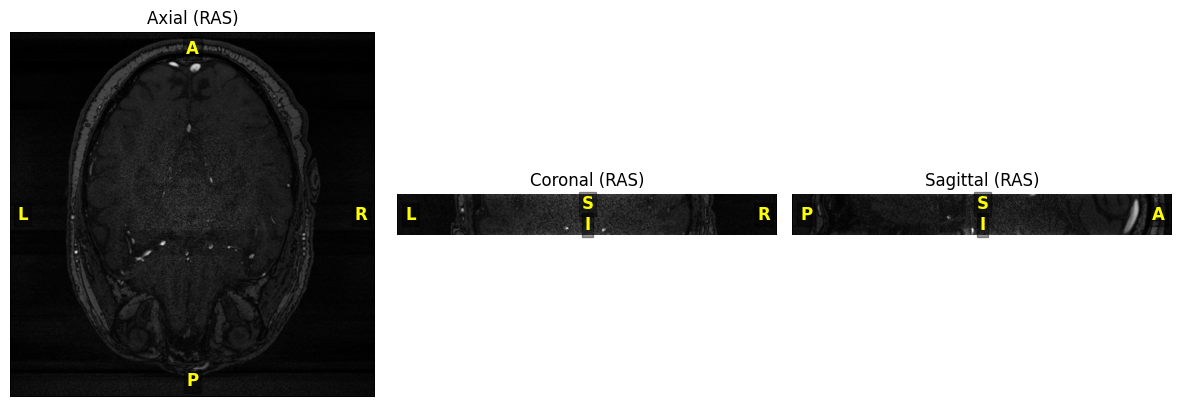

In [8]:
# Reorient LAS to RAS for visualization (with labels)
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nibabel.orientations import aff2axcodes, io_orientation
from nibabel.orientations import apply_orientation

# Path to the NIfTI file (adjust to your case)
nifti_path = "../data/nifti_patients/001_20240313_3T/Magnitude_NoProto_WIP_pc3d1r3.nii.gz"

img = nib.load(nifti_path)
data = img.get_fdata()
affine = img.affine

print("Current orientation (data):", aff2axcodes(affine))

# Force reorient to RAS for display
ornt = io_orientation(affine)
ras_ornt = nib.orientations.axcodes2ornt(("R", "A", "S"))
transform = nib.orientations.ornt_transform(ornt, ras_ornt)
data_ras = apply_orientation(data, transform)

# If 4D, pick a timepoint
if data_ras.ndim == 4:
    t = data_ras.shape[3] // 2
    vol = data_ras[:, :, :, t]
    print("Showing t =", t)
else:
    vol = data_ras

def add_labels(ax, left, right, top, bottom):
    ax.text(0.02, 0.5, left, transform=ax.transAxes, va="center", ha="left",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.text(0.98, 0.5, right, transform=ax.transAxes, va="center", ha="right",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.text(0.5, 0.98, top, transform=ax.transAxes, va="top", ha="center",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.text(0.5, 0.02, bottom, transform=ax.transAxes, va="bottom", ha="center",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))

# Central slices
z = vol.shape[2] // 2
y = vol.shape[1] // 2
x = vol.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axial = vol[:, :, z].T
axes[0].imshow(axial, cmap="gray", origin="lower")
axes[0].set_title("Axial (RAS)")
axes[0].axis("off")
add_labels(axes[0], left="L", right="R", top="A", bottom="P")

coronal = vol[:, y, :].T
axes[1].imshow(coronal, cmap="gray", origin="lower")
axes[1].set_title("Coronal (RAS)")
axes[1].axis("off")
add_labels(axes[1], left="L", right="R", top="S", bottom="I")

sagittal = vol[x, :, :].T
axes[2].imshow(sagittal, cmap="gray", origin="lower")
axes[2].set_title("Sagittal (RAS)")
axes[2].axis("off")
add_labels(axes[2], left="P", right="A", top="S", bottom="I")

plt.tight_layout()
plt.show()

# Note: aff2axcodes prints header orientation (still LAS),
# but the displayed views are reoriented to RAS.

--- Alignment Check ---
LR (3T) orientation: ('R', 'A', 'S')
HR (7T) orientation: ('R', 'A', 'S')
LR (3T) shape (RAS): (448, 448, 48) t= 4
HR (7T) shape (RAS): (448, 448, 48) t= 14
Origin LR (RAS): [-113.27775574  -90.62426758  -10.84573078]
Origin HR (RAS): [-108.12259674 -109.46617126  -27.93437767]
Euclidean distance between origins: 25.9541 mm
>> WARNING: Origins are different. Registration is REQUIRED.


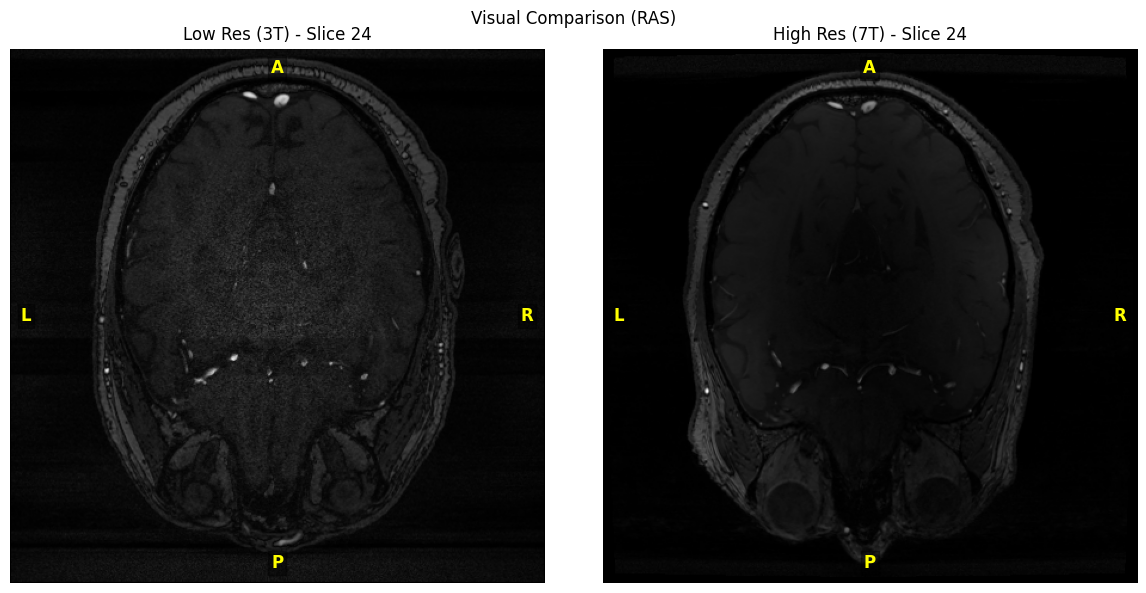

In [11]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import os
from nibabel.orientations import aff2axcodes, io_orientation, apply_orientation

def _reorient_to_ras(data, affine):
    ornt = io_orientation(affine)
    ras_ornt = nib.orientations.axcodes2ornt(("R", "A", "S"))
    transform = nib.orientations.ornt_transform(ornt, ras_ornt)
    data_ras = apply_orientation(data, transform)
    affine_ras = affine @ nib.orientations.inv_ornt_aff(transform, data.shape[:3])
    return data_ras, affine_ras

def _prepare_volume(img):
    data = img.get_fdata()
    affine = img.affine
    data_ras, affine_ras = _reorient_to_ras(data, affine)
    if data_ras.ndim == 4:
        t = data_ras.shape[3] // 2
        vol = data_ras[:, :, :, t]
    else:
        t = None
        vol = data_ras
    return vol, affine_ras, t

def add_labels(ax, left, right, top, bottom):
    ax.text(0.02, 0.5, left, transform=ax.transAxes, va="center", ha="left",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.text(0.98, 0.5, right, transform=ax.transAxes, va="center", ha="right",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.text(0.5, 0.98, top, transform=ax.transAxes, va="top", ha="center",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.text(0.5, 0.02, bottom, transform=ax.transAxes, va="bottom", ha="center",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))

def check_alignment(lr_path, hr_path):
    """
    Checks alignment between Low Res (3T) and High Res (7T) images.
    1. Compares physical coordinates (affine).
    2. Reorients both to RAS for a consistent visual check.
    3. Handles 3D/4D volumes by selecting the middle timepoint.
    """
    if not os.path.exists(lr_path) or not os.path.exists(hr_path):
        print("Error: Check file paths.")
        return

    # Load NIfTI files
    img_lr = nib.load(lr_path)
    img_hr = nib.load(hr_path)

    print("--- Alignment Check ---")
    print("LR (3T) orientation:", aff2axcodes(img_lr.affine))
    print("HR (7T) orientation:", aff2axcodes(img_hr.affine))

    # Prepare RAS volumes
    vol_lr, affine_lr, t_lr = _prepare_volume(img_lr)
    vol_hr, affine_hr, t_hr = _prepare_volume(img_hr)

    print("LR (3T) shape (RAS):", vol_lr.shape, "t=", t_lr)
    print("HR (7T) shape (RAS):", vol_hr.shape, "t=", t_hr)

    # 1. Check Origin Difference (Translation) in RAS
    origin_lr = affine_lr[:3, 3]
    origin_hr = affine_hr[:3, 3]
    dist = np.linalg.norm(origin_lr - origin_hr)
    print("Origin LR (RAS):", origin_lr)
    print("Origin HR (RAS):", origin_hr)
    print(f"Euclidean distance between origins: {dist:.4f} mm")
    if dist > 0.1:
        print(">> WARNING: Origins are different. Registration is REQUIRED.")
    else:
        print(">> INFO: Origins are close. Check visual alignment manually.")

    # 2. Visual Check (Center Slice)
    z_lr = vol_lr.shape[2] // 2
    z_hr = vol_hr.shape[2] // 2

    plt.figure(figsize=(12, 6))

    # Plot LR
    plt.subplot(1, 2, 1)
    plt.imshow(vol_lr[:, :, z_lr].T, cmap="gray", origin="lower")
    plt.title(f"Low Res (3T) - Slice {z_lr}")
    plt.axis("off")
    add_labels(plt.gca(), left="L", right="R", top="A", bottom="P")

    # Plot HR
    plt.subplot(1, 2, 2)
    plt.imshow(vol_hr[:, :, z_hr].T, cmap="gray", origin="lower")
    plt.title(f"High Res (7T) - Slice {z_hr}")
    plt.axis("off")
    add_labels(plt.gca(), left="L", right="R", top="A", bottom="P")

    plt.suptitle("Visual Comparison (RAS)")
    plt.tight_layout()
    plt.show()

# --- CONFIGURATION ---
# Use Magnitude images for alignment checks (they have the best anatomical detail)
lr_file = "../data/nifti_patients/001_20240313_3T/Magnitude_NoProto_WIP_pc3d1r3.nii.gz"
hr_file = "../data/nifti_patients/001_20240313_7T/Magnitude_NoProto_WIP_fl3d1r3.nii.gz"

check_alignment(lr_file, hr_file)

--- V24: Registro Mejorado (N4 Bias Corr + Affine) ---
   [1/7] Cargando y Reorientando Imágenes...
      Fixed Origin: (-113.35580622926646, -116.1752523758172, -5.79821888186595)
      Moving Origin: (-121.11005015620626, -119.31069129638206, 27.186090206102953)
   [2/7] Aplicando N4 Bias Field Correction...
   [3/7] Preparando Máscaras...
      -> Generando máscara Fixed (otsu+morphology)
      -> Generando máscara Moving (otsu+morphology)
   [4/7] Inicializando Transform (Affine)...


 bad det -1 v 1 u -1
 bad det -1 v 1 u -1 new 1


   [5/7] Ejecutando Registro (Affine)...
   [6/7] Warping (Imagen + Máscara)...
   [7/7] Visualizando...


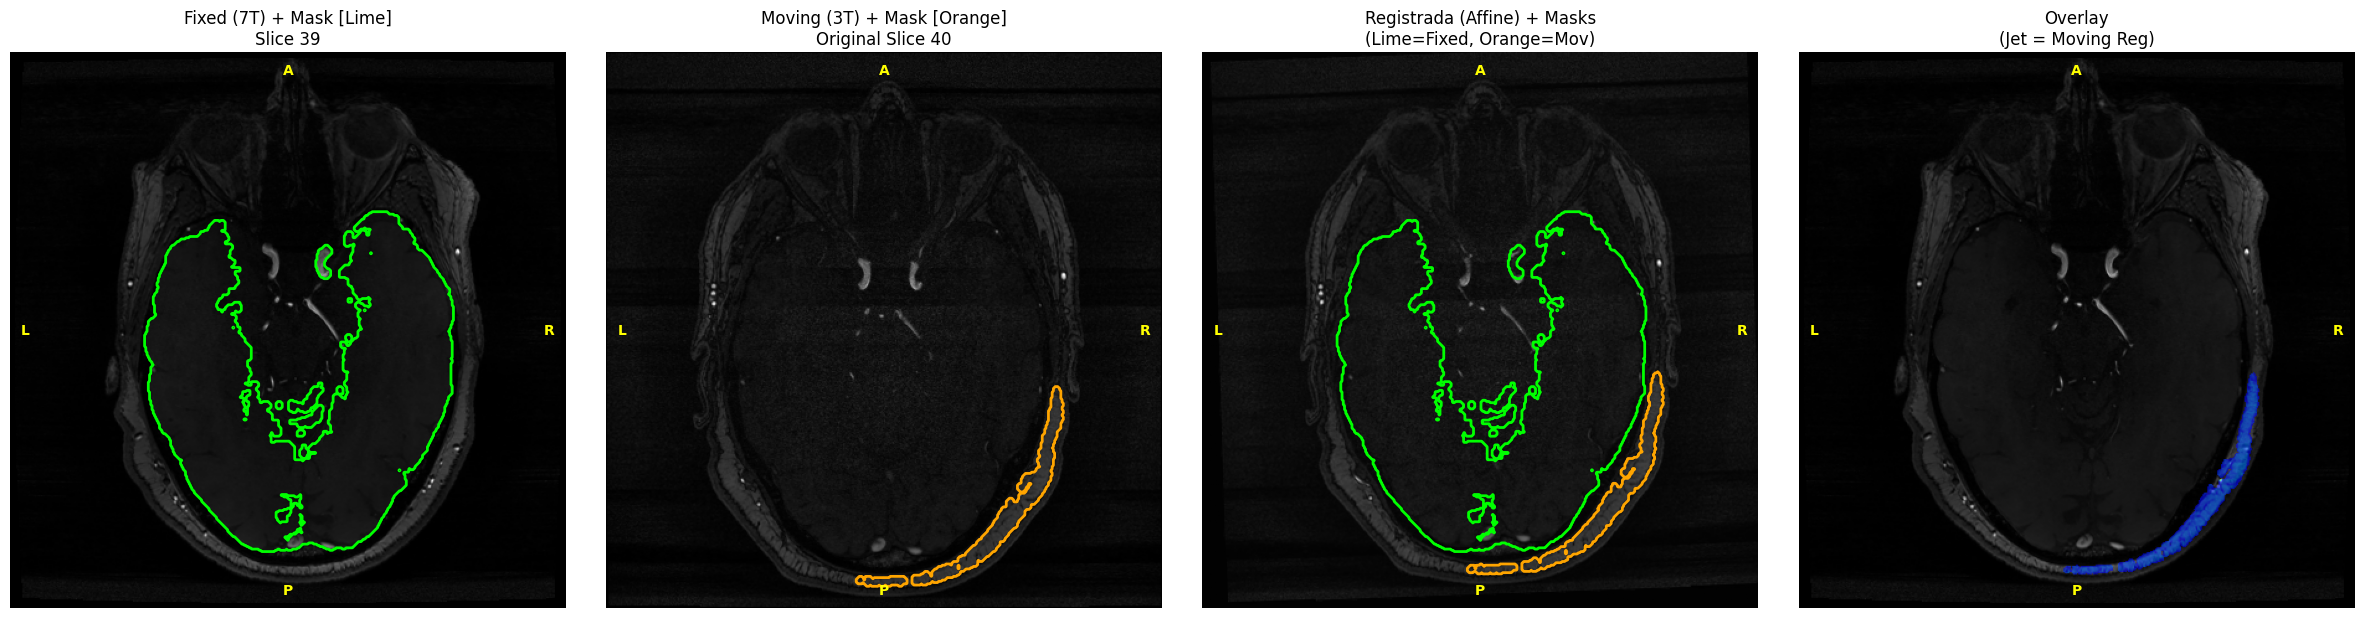

In [30]:
import os
import matplotlib.pyplot as plt
import numpy as np

try:
    import ants
except ImportError as e:
    raise ImportError("ANTsPy not installed. Install with: pip install antspyx") from e

# --- UTILIDADES VISUALES ---
def add_labels_ras(ax):
    """Etiquetas asumiendo orientación RAS"""
    ax.text(0.02, 0.5, "L", transform=ax.transAxes, va="center", ha="left", color="yellow", fontweight="bold")
    ax.text(0.98, 0.5, "R", transform=ax.transAxes, va="center", ha="right", color="yellow", fontweight="bold")
    ax.text(0.5, 0.98, "A", transform=ax.transAxes, va="top", ha="center", color="yellow", fontweight="bold")
    ax.text(0.5, 0.02, "P", transform=ax.transAxes, va="bottom", ha="center", color="yellow", fontweight="bold")

def _to_numpy(img):
    arr = img.numpy()
    if arr.ndim == 4: arr = arr[..., 0]
    return arr

def _load_and_prep(path_or_img, is_mask=False):
    """Carga, maneja 4D y reorienta a RAS."""
    if isinstance(path_or_img, str):
        raw = ants.image_read(path_or_img)
    else:
        raw = path_or_img
        
    # 4D -> 3D (Extraction)
    if raw.dimension == 4:
        img_3d = ants.slice_image(raw, axis=3, idx=0)
    else:
        img_3d = raw
        
    # Reorient to RAS
    img_ras = ants.reorient_image2(img_3d, "RAS")
    return img_ras

def register_ras_slab_fixed(path_fixed_hr, path_moving_lr, path_fixed_mask=None, path_moving_mask=None):
    print("--- V24: Registro Mejorado (N4 Bias Corr + Affine) ---")
    
    # 1. CARGA IMÁGENES
    print("   [1/7] Cargando y Reorientando Imágenes...")
    fixed = _load_and_prep(path_fixed_hr)
    moving = _load_and_prep(path_moving_lr)

    print(f"      Fixed Origin: {fixed.origin}")
    print(f"      Moving Origin: {moving.origin}")

    # 2. PRE-PROCESAMIENTO (N4 Bias Correction)
    # Fundamental para 7T, elimina variaciones de intensidad que confunden el registro
    print("   [2/7] Aplicando N4 Bias Field Correction...")
    fixed = ants.n4_bias_field_correction(fixed)
    moving = ants.n4_bias_field_correction(moving)

    # 3. MÁSCARAS
    print("   [3/7] Preparando Máscaras...")
    
    if path_fixed_mask and os.path.exists(path_fixed_mask):
        print("      -> Usando máscara Fixed externa")
        mask_fixed = _load_and_prep(path_fixed_mask, is_mask=True)
    else:
        print("      -> Generando máscara Fixed (otsu+morphology)")
        # ants.get_mask simple a veces falla en 7T, otsu con cleanup es decente tras N4
        mask_fixed = ants.get_mask(fixed, cleanup=2)

    if path_moving_mask and os.path.exists(path_moving_mask):
        print("      -> Usando máscara Moving externa")
        mask_moving = _load_and_prep(path_moving_mask, is_mask=True)
    else:
        print("      -> Generando máscara Moving (otsu+morphology)")
        mask_moving = ants.get_mask(moving, cleanup=2)

    # 4. INICIALIZACIÓN
    print("   [4/7] Inicializando Transform (Affine)...")
    init_tx = ants.affine_initializer(
        fixed_image=fixed,
        moving_image=moving,
        search_factor=20,
        radian_fraction=0.1,
        use_principal_axis=True,
        local_search_iterations=10,
        mask=mask_fixed
    )

    # 5. REGISTRO (Affine en vez de Rigid para corregir distorsiones geométricas 7T)
    print("   [5/7] Ejecutando Registro (Affine)...")
    tx = ants.registration(
        fixed=fixed,
        moving=moving,
        type_of_transform="Affine",  # Rigid -> Affine mejora scaling/shearing
        initial_transform=init_tx,
        aff_metric="mattes",
        aff_sampling=32,
        reg_iterations=(100, 100, 70, 20), # Más iteraciones
        mask=mask_fixed,
        moving_mask=mask_moving,
        verbose=False
    )

    # 6. APLICAR TRANSFORMACIÓN
    print("   [6/7] Warping (Imagen + Máscara)...")
    
    warped_img = ants.apply_transforms(
        fixed=fixed,
        moving=moving,
        transformlist=tx["fwdtransforms"],
        interpolator="bSpline"
    )
    
    warped_mask = ants.apply_transforms(
        fixed=fixed,
        moving=mask_moving,
        transformlist=tx["fwdtransforms"],
        interpolator="nearestNeighbor"
    )

    # --- VISUALIZACIÓN ---
    print("   [7/7] Visualizando...")
    f_np = _to_numpy(fixed)
    m_np = _to_numpy(moving)
    w_np = _to_numpy(warped_img)
    
    mf_np = _to_numpy(mask_fixed)
    mm_np = _to_numpy(mask_moving)
    wm_np = _to_numpy(warped_mask)

    def normalize(arr):
        return (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)

    f_np = normalize(f_np)
    w_np = normalize(w_np)
    m_np = normalize(m_np)

    # Seleccionar slice con mucho cerebro en la imagen registrada
    slice_sums = np.sum(wm_np, axis=(0,1))
    z_best = np.argmax(slice_sums)
    z_orig = np.argmax(np.sum(mm_np, axis=(0,1)))

    fig, axes = plt.subplots(1, 4, figsize=(24, 6))

    def plot_contour(ax, mask_slice, color):
        if np.sum(mask_slice) > 0:
            ax.contour(mask_slice.T, levels=[0.5], colors=color, linewidths=2, origin='lower')

    # 1. Fixed (7T)
    axes[0].imshow(f_np[:, :, z_best].T, cmap='gray', origin='lower')
    plot_contour(axes[0], mf_np[:, :, z_best], 'lime')
    axes[0].set_title(f"Fixed (7T) + Mask [Lime]\nSlice {z_best}")
    add_labels_ras(axes[0])
    axes[0].axis('off')

    # 2. Moving Original (3T)
    axes[1].imshow(m_np[:, :, z_orig].T, cmap='gray', origin='lower')
    plot_contour(axes[1], mm_np[:, :, z_orig], 'orange')
    axes[1].set_title(f"Moving (3T) + Mask [Orange]\nOriginal Slice {z_orig}")
    add_labels_ras(axes[1])
    axes[1].axis('off')

    # 3. Resultado (Warped)
    axes[2].imshow(w_np[:, :, z_best].T, cmap='gray', origin='lower')
    plot_contour(axes[2], wm_np[:, :, z_best], 'orange') 
    plot_contour(axes[2], mf_np[:, :, z_best], 'lime')  
    axes[2].set_title(f"Registrada (Affine) + Masks\n(Lime=Fixed, Orange=Mov)")
    add_labels_ras(axes[2])
    axes[2].axis('off')

    # 4. Overlay
    alpha_mask = np.where(wm_np[:, :, z_best] > 0.5, 0.6, 0.0)
    axes[3].imshow(f_np[:, :, z_best].T, cmap='gray', origin='lower')
    axes[3].imshow(w_np[:, :, z_best].T, cmap='jet', origin='lower', alpha=alpha_mask.T)
    axes[3].set_title("Overlay\n(Jet = Moving Reg)")
    add_labels_ras(axes[3])
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

    return tx['fwdtransforms']

# --- EJECUTAR ---
hr_mag = "../data/nifti_patients/001_20240313_7T/Magnitude_NoProto_WIP_fl3d1r3.nii.gz"
lr_mag = "../data/nifti_patients/001_20240313_3T/Magnitude_NoProto_WIP_pc3d1r3.nii.gz"

transforms = register_ras_slab_fixed(hr_mag, lr_mag)

--- Registro Avanzado (Masked + BOLDRigid + SyN) ---
Generando máscaras robustas...


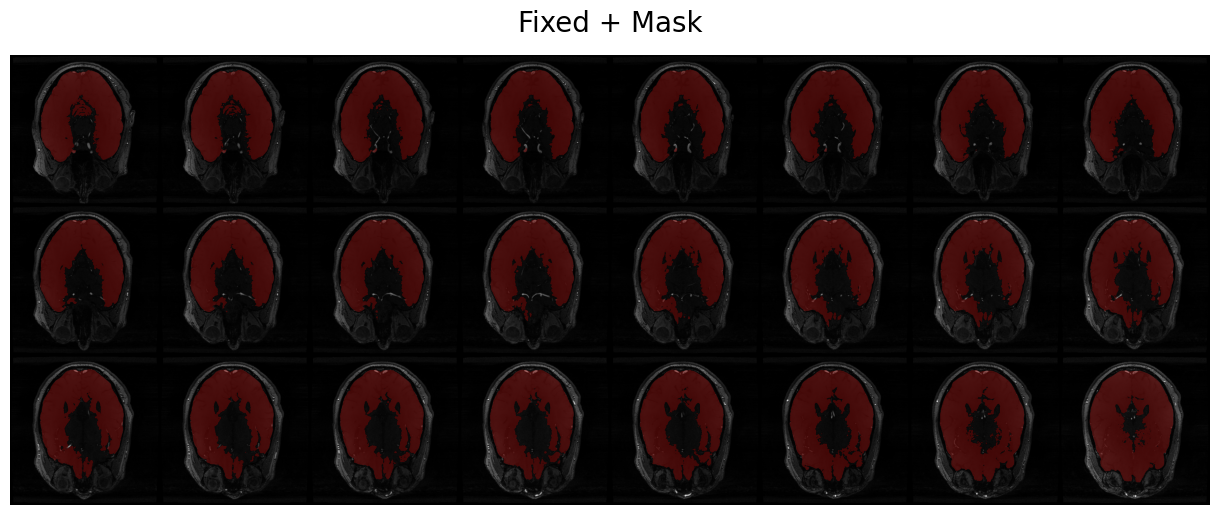

Paso 1: Rigid (BOLDRigid)...


In [ ]:
import ants

print("--- Registro Avanzado (Masked + BOLDRigid + SyN) ---")
# 1. Cargar Imágenes RAS
raw_fixed = ants.image_read("../data/nifti_patients/001_20240313_7T/Magnitude_NoProto_WIP_fl3d1r3.nii.gz")
raw_moving = ants.image_read("../data/nifti_patients/001_20240313_3T/Magnitude_NoProto_WIP_pc3d1r3.nii.gz")

fixed = ants.reorient_image2(ants.slice_image(raw_fixed, axis=3, idx=0) if raw_fixed.dimension==4 else raw_fixed, "RAS")
moving = ants.reorient_image2(ants.slice_image(raw_moving, axis=3, idx=0) if raw_moving.dimension==4 else raw_moving, "RAS")

# 2. Máscaras Robustas (tu snippet adaptado)
# Mean * 1.1 suele funcionar bien para separar cerebro de fondo ruidoso
print("Generando máscaras robustas...")
mask_fixed = ants.get_mask(fixed, low_thresh=fixed.mean() * 0.8, cleanup=3).iMath_fill_holes()
mask_moving = ants.get_mask(moving, low_thresh=moving.mean() * 0.8, cleanup=3).iMath_fill_holes()

# Visualizar Máscara
ants.plot(fixed, mask_fixed, axis=2, overlay_alpha=0.5, ncol=8, nslices=24, title="Fixed + Mask")

# 3. Registro Rígido (Inicialización para el SyN) - Usando imágenes ENMASCARADAS
print("Paso 1: Rigid (BOLDRigid)...")
# Multiplicar por máscara elimina el fondo para el registro
tx_rig = ants.registration(
    fixed=fixed * mask_fixed, 
    moving=moving * mask_moving, 
    type_of_transform="BOLDRigid" 
)

# 4. Registro Deformable (SyN) - Ajuste fino no lineal
print("Paso 2: SyN (Deformable)...")
tx_syn = ants.registration(
    fixed=fixed * mask_fixed, 
    moving=moving * mask_moving, 
    type_of_transform="SyNOnly", # Solo la parte deformable
    initial_transform=tx_rig['fwdtransforms'], # Empezar desde el rígido
    syn_metric='CC', 
    syn_sampling=32, 
    reg_iterations=(100, 70, 50, 20) # Iteraciones más robustas
)

# 5. Aplicar Transformación Final a la imagen original (sin enmascarar)
print("Aplicando transformaciones...")
# Se aplican ambas: primero SyN (tx_syn), luego Rígida (tx_rig está implícita en la init de syn si usas la lista completa)
# Pero ojo: SyNOnly devuelve los warps. La lista completa es:
# SyN warp + SyN affine (que es identidad en SyNOnly) + Rigid transform
full_transforms = tx_syn['fwdtransforms'] + tx_rig['fwdtransforms']

warped_img = ants.apply_transforms(
    fixed=fixed, 
    moving=moving, 
    transformlist=full_transforms
)

# Visualizar
print("Resultado Final (SyN):")
ants.plot(fixed, warped_img, axis=2, overlay_alpha=0.5, ncol=8, nslices=24, title="Registro SyN Final")

In [1]:
import nibabel as nib
import numpy as np

img = nib.load("../data/nifti_patients/001_20240313_3T/Magnitude_NoProto_WIP_pc3d1r3.nii.gz")
data = img.get_fdata()
affine = img.affine
print("Image shape:", data.shape)
print("Affine:\n", affine)

Image shape: (448, 448, 48, 9)
Affine:
 [[ 4.98617113e-01  2.26420555e-02  2.94672418e-02 -1.13277756e+02]
 [-1.85544081e-02  4.95204479e-01 -6.65451661e-02 -9.06242676e+01]
 [-3.21980566e-02  6.52676150e-02  4.94675070e-01 -1.08457308e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


## Check venc